# EVRP RL Framework: PPO vs SAC Ablation Study

This notebook demonstrates the modular RL framework for Electric Vehicle Routing Problems (EVRP).

We'll run experiments comparing A2C and SAC agents with different encoder architectures.

## Setup

In [5]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.framework import (
    EnvFactory,
    AgentFactory,
    ExperimentRunner,
    ConfigLoader,
    create_experiment_config,
)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

✓ Imports successful


## 1. Define Experiment Configurations

We'll compare:
- **A2C + MLP**: Baseline with simple MLP encoder
- **A2C + GAT**: A2C with Graph Attention Network encoder  
- **SAC + MLP**: SAC with MLP encoder
- **SAC + GAT**: SAC with GAT encoder

In [6]:
# Common environment configuration
env_config = {
    'num_customers': 5,   # Further reduced to verify solvability
    'num_chargers': 2,
    'battery_capacity': 500.0,
    'cargo_capacity': 200.0,
    'time_limit': 500,
    'seed': 42,
}

# Common run configuration
run_config = {
    'epochs': 100,  # More training
    'eval_frequency': 10,
    'save_frequency': 25,
    'max_steps_per_episode': 500,  # Critical: allow longer routes
    'num_eval_episodes': 10,  # More stable eval
    'seed': 42,
}

# A2C configurations
a2c_mlp_config = create_experiment_config(
    env_config=env_config,
    agent_config={
        'type': 'a2c',
        'encoder': {
            'type': 'mlp',
            'embed_dim': 128,
            'hidden_dim': 256,
            'num_layers': 3,
        },
        'hyperparameters': {
            'lr': 3e-4,
            'gamma': 0.99,
            'entropy_coef': 0.01,
            'hidden_dim': 256,
        },
    },
    run_config={**run_config, 'name': 'a2c_mlp'},
)

a2c_gat_config = create_experiment_config(
    env_config=env_config,
    agent_config={
        'type': 'a2c',
        'encoder': {
            'type': 'gat',
            'embed_dim': 128,
            'num_layers': 3,
            'num_heads': 8,
        },
        'hyperparameters': {
            'lr': 3e-4,
            'gamma': 0.99,
            'entropy_coef': 0.01,
            'hidden_dim': 256,
        },
    },
    run_config={**run_config, 'name': 'a2c_gat'},
)

# SAC configurations
sac_mlp_config = create_experiment_config(
    env_config=env_config,
    agent_config={
        'type': 'sac',
        'encoder': {
            'type': 'mlp',
            'embed_dim': 128,
            'hidden_dim': 256,
            'num_layers': 3,
        },
        'hyperparameters': {
            'lr': 3e-4,
            'gamma': 0.99,
            'tau': 0.005,
            'alpha': 'auto',
            'hidden_dim': 256,
            'buffer_size': 10000,
            'batch_size': 32,
            'learning_starts': 100,
        },
    },
    run_config={**run_config, 'name': 'sac_mlp'},
)

sac_gat_config = create_experiment_config(
    env_config=env_config,
    agent_config={
        'type': 'sac',
        'encoder': {
            'type': 'gat',
            'embed_dim': 128,
            'num_layers': 3,
            'num_heads': 8,
        },
        'hyperparameters': {
            'lr': 3e-4,
            'gamma': 0.99,
            'tau': 0.005,
            'alpha': 'auto',
            'hidden_dim': 256,
            'buffer_size': 10000,
            'batch_size': 32,
            'learning_starts': 100,
        },
    },
    run_config={**run_config, 'name': 'sac_gat'},
)

experiments = {
    'A2C + MLP': a2c_mlp_config,
    'A2C + GAT': a2c_gat_config,
    'SAC + MLP': sac_mlp_config,
    'SAC + GAT': sac_gat_config,
}

print(f"✓ Configured {len(experiments)} experiments")

✓ Configured 4 experiments


## 1.5. Environment Diagnostic Check

Let's verify the environment can complete routes before training.

In [7]:
# Quick diagnostic: test if environment is solvable
print("🔍 Diagnostic: Testing environment feasibility")
print("=" * 60)

test_env = EnvFactory.create(env_config)
obs, _ = test_env.reset(seed=42)

success_count = 0
best_route_length = 0

num_customers = env_config['num_customers']
num_chargers = env_config['num_chargers']
charger_nodes = list(range(num_customers + 1, num_customers + num_chargers + 1))

depot_node = 0
rng = np.random.default_rng(42)


def select_action(obs, unvisited_customers, customers_visited):
    valid_mask = np.asarray(obs['valid_actions_mask']).astype(bool)
    valid_actions = np.where(valid_mask)[0]
    if len(valid_actions) == 0:
        return None

    current_node = int(np.asarray(obs['current_node']).item())
    dist = np.asarray(obs.get('distance_matrix', None))

    # If all customers visited, try returning to depot
    if len(customers_visited) == num_customers and depot_node in valid_actions:
        return depot_node

    # Prefer nearest unvisited customer if possible
    candidate_customers = [c for c in unvisited_customers if c in valid_actions]
    if dist is not None and len(candidate_customers) > 0:
        nearest = min(candidate_customers, key=lambda c: dist[current_node, c])
        return nearest

    # Otherwise prefer nearest charger if possible
    candidate_chargers = [c for c in charger_nodes if c in valid_actions]
    if dist is not None and len(candidate_chargers) > 0:
        nearest = min(candidate_chargers, key=lambda c: dist[current_node, c])
        return nearest

    # Fallback: random valid action
    return rng.choice(valid_actions)


for trial in range(5):
    obs, _ = test_env.reset(seed=42 + trial)
    total_reward = 0
    route_length = 0
    customers_visited = set()
    info = {}

    for step in range(run_config['max_steps_per_episode']):
        unvisited_customers = set(range(1, num_customers + 1)) - customers_visited
        action = select_action(obs, unvisited_customers, customers_visited)

        if action is None:
            print(f"  Trial {trial + 1}: No valid actions at step {step}")
            break

        obs, reward, terminated, truncated, info = test_env.step(int(action))

        total_reward += reward
        route_length += 1

        current_node = int(np.asarray(obs['current_node']).item())
        if 1 <= current_node <= num_customers:
            customers_visited.add(current_node)

        if terminated or truncated:
            if info.get('success', False):
                success_count += 1
            break

    best_route_length = max(best_route_length, route_length)
    print(
        f"  Trial {trial + 1}: Reward={total_reward:.1f}, "
        f"Route Length={route_length}, Customers Visited={len(customers_visited)}, "
        f"Success={info.get('success', False)}"
    )
    if len(customers_visited) == num_customers:
        print(f"    All customers visited. info keys: {list(info.keys())}")

print("=" * 60)
print(f"Heuristic Success Rate: {success_count}/5 = {success_count*20:.0f}%")
print("If all customers visited but success=False, the env likely requires return to depot.")
print("=" * 60)


🔍 Diagnostic: Testing environment feasibility
  Trial 1: Reward=-1.0, Route Length=6, Customers Visited=5, Success=True
    All customers visited. info keys: ['current_node', 'current_battery', 'current_cargo', 'visited_customers', 'total_distance', 'distance', 'node_type', 'all_customers_visited', 'success', 'depot_visits', 'charger_visits', 'current_step', 'time_limit']
  Trial 2: Reward=-1.0, Route Length=6, Customers Visited=5, Success=True
    All customers visited. info keys: ['current_node', 'current_battery', 'current_cargo', 'visited_customers', 'total_distance', 'distance', 'node_type', 'all_customers_visited', 'success', 'depot_visits', 'charger_visits', 'current_step', 'time_limit']
  Trial 3: Reward=-1.0, Route Length=6, Customers Visited=5, Success=True
    All customers visited. info keys: ['current_node', 'current_battery', 'current_cargo', 'visited_customers', 'total_distance', 'distance', 'node_type', 'all_customers_visited', 'success', 'depot_visits', 'charger_visits

## 2. Run Experiments

⚠️ **Note**: Running all experiments will take some time. For a quick demo, reduce `epochs` or comment out some experiments.

In [8]:
# Store results
results = {}

for name, config in experiments.items():
    print(f"\n{'='*60}")
    print(f"Running: {name}")
    print(f"{'='*60}")
    
    try:
        # Create environment and agent
        env = EnvFactory.create(config['env'])
        agent = AgentFactory.create(config['agent'], env.action_space.n)
        
        # Create and run experiment
        # Note: config should already have 'env', 'agent', 'run' keys from create_experiment_config
        runner = ExperimentRunner(
            env=env,
            agent=agent,
            config=config,
            log_dir=f'results/ablation/{name.replace(" ", "_").lower()}',
            checkpoint_dir=f'checkpoints/ablation/{name.replace(" ", "_").lower()}',
        )
        
        # Train the agent
        runner.train()
        
        # Store runner for later analysis
        results[name] = runner
        
        print(f"\n✓ Completed: {name}")
        print(f"  Best reward: {runner.best_reward:.2f}")
        
    except Exception as e:
        print(f"\n✗ Error running {name}: {str(e)}")
        import traceback
        traceback.print_exc()

print("\n" + "="*60)
print("All experiments completed!")
print("="*60)


Running: A2C + MLP
Starting training for 100 epochs
Log dir: results/ablation/a2c_+_mlp/a2c_mlp_20260128_174740
Checkpoint dir: checkpoints/ablation/a2c_+_mlp/a2c_mlp_20260128_174740
------------------------------------------------------------
Epoch 10/100 | Reward: -4.95 ± 2.11 | Length: 12.3 | Loss: -0.1960

Evaluating at epoch 10...
  Eval Reward: -222.85
  Success Rate: 100.00%
  Avg Route Length: 336.86
  Avg Charge Visits: 445.5
  New best model saved! (reward: -222.85)
------------------------------------------------------------
Epoch 20/100 | Reward: -54.30 ± 147.57 | Length: 61.2 | Loss: -0.1389

Evaluating at epoch 20...
  Eval Reward: -198.20
  Success Rate: 100.00%
  Avg Route Length: 339.81
  Avg Charge Visits: 396.0
  New best model saved! (reward: -198.20)
------------------------------------------------------------
Epoch 30/100 | Reward: -52.55 ± 147.82 | Length: 59.0 | Loss: -0.0102

Evaluating at epoch 30...
  Eval Reward: -50.50
  Success Rate: 90.00%
  Avg Route Le

## 3. Compare Training Curves

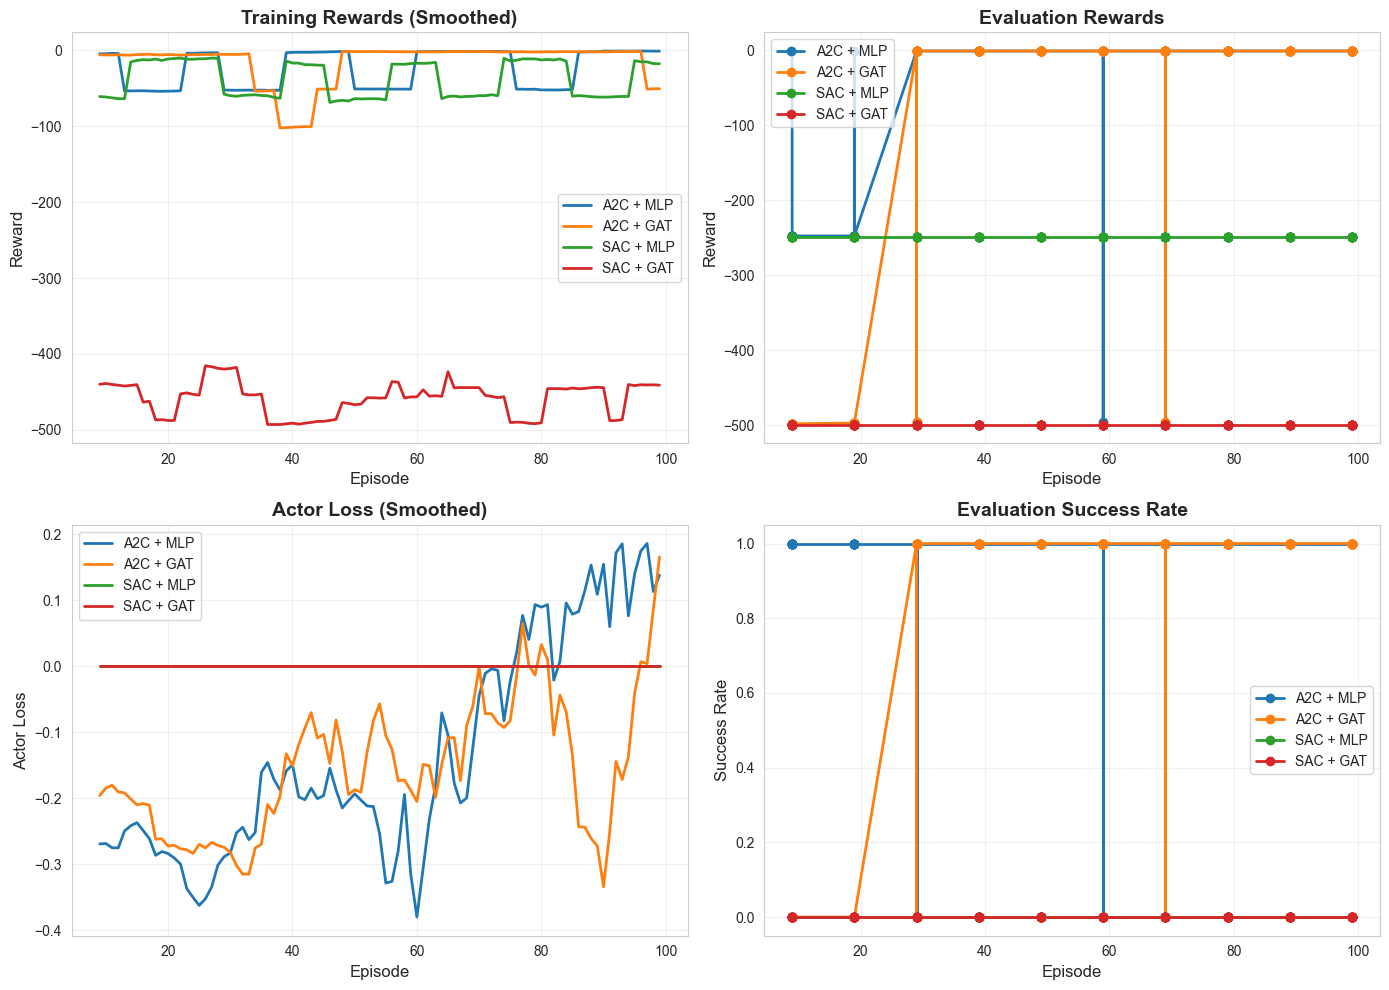

✓ Training curves plotted


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training rewards
ax = axes[0, 0]
for name, runner in results.items():
    episodes = runner.logger.metrics['train']['episodes']
    rewards = runner.logger.metrics['train']['rewards']
    # Smooth with moving average
    window = 10
    if len(rewards) >= window:
        rewards_smooth = np.convolve(rewards, np.ones(window)/window, mode='valid')
        episodes_smooth = episodes[window-1:]
        ax.plot(episodes_smooth, rewards_smooth, label=name, linewidth=2)
    else:
        ax.plot(episodes, rewards, label=name, linewidth=2)

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Reward', fontsize=12)
ax.set_title('Training Rewards (Smoothed)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Evaluation rewards
ax = axes[0, 1]
for name, runner in results.items():
    if len(runner.logger.metrics['eval']['episodes']) > 0:
        episodes = runner.logger.metrics['eval']['episodes']
        rewards = runner.logger.metrics['eval']['rewards']
        ax.plot(episodes, rewards, marker='o', label=name, linewidth=2)

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Reward', fontsize=12)
ax.set_title('Evaluation Rewards', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Actor losses
ax = axes[1, 0]
for name, runner in results.items():
    episodes = runner.logger.metrics['train']['episodes']
    losses = runner.logger.metrics['train']['actor_losses']
    if len(losses) > 0:
        # Smooth
        window = 10
        if len(losses) >= window:
            losses_smooth = np.convolve(losses, np.ones(window)/window, mode='valid')
            episodes_smooth = episodes[window-1:]
            ax.plot(episodes_smooth, losses_smooth, label=name, linewidth=2)
        else:
            ax.plot(episodes, losses, label=name, linewidth=2)

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Actor Loss', fontsize=12)
ax.set_title('Actor Loss (Smoothed)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Success rate
ax = axes[1, 1]
for name, runner in results.items():
    if len(runner.logger.metrics['eval']['success_rate']) > 0:
        episodes = runner.logger.metrics['eval']['episodes']
        success_rate = runner.logger.metrics['eval']['success_rate']
        ax.plot(episodes, success_rate, marker='o', label=name, linewidth=2)

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Success Rate', fontsize=12)
ax.set_title('Evaluation Success Rate', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.savefig('results/ablation/training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training curves plotted")

## 4. Statistical Analysis

In [10]:
# Compute final performance metrics
performance_summary = {}

for name, runner in results.items():
    # Get last 10 evaluation episodes
    eval_rewards = runner.logger.metrics['eval']['rewards'][-10:]
    eval_success = runner.logger.metrics['eval']['success_rate'][-10:]
    eval_route_lengths = runner.logger.metrics['eval']['route_lengths'][-10:]
    eval_charge_visits = runner.logger.metrics['eval']['charge_visits'][-10:]
    
    if len(eval_rewards) > 0:
        performance_summary[name] = {
            'Mean Reward': np.mean(eval_rewards),
            'Std Reward': np.std(eval_rewards),
            'Success Rate': np.mean(eval_success),
            'Mean Route Length': np.mean(eval_route_lengths),
            'Mean Charge Visits': np.mean(eval_charge_visits),
            'Best Reward': runner.best_reward,
        }

# Display as table
import pandas as pd

df = pd.DataFrame(performance_summary).T
df = df.round(3)
print("\n" + "="*80)
print("FINAL PERFORMANCE COMPARISON (Last 10 Eval Episodes)")
print("="*80)
print(df.to_string())
print("="*80)

# Highlight best performers
print("\n📊 Best Performers:")
print(f"  Highest Reward: {df['Mean Reward'].idxmax()} ({df['Mean Reward'].max():.3f})")
print(f"  Highest Success Rate: {df['Success Rate'].idxmax()} ({df['Success Rate'].max():.1%})")
print(f"  Shortest Routes: {df['Mean Route Length'].idxmin()} ({df['Mean Route Length'].min():.2f})")
print(f"  Fewest Charges: {df['Mean Charge Visits'].idxmin()} ({df['Mean Charge Visits'].min():.2f})")


FINAL PERFORMANCE COMPARISON (Last 10 Eval Episodes)
           Mean Reward  Std Reward  Success Rate  Mean Route Length  Mean Charge Visits  Best Reward
A2C + MLP         -1.0         0.0           1.0            352.013                 0.0         -1.0
A2C + GAT         -1.0         0.0           1.0            324.277                 0.0         -1.0
SAC + MLP       -248.5         0.0           0.0            221.104               497.0       -248.5
SAC + GAT       -499.0         0.0           0.0            142.083                 0.0       -499.0

📊 Best Performers:
  Highest Reward: A2C + MLP (-1.000)
  Highest Success Rate: A2C + MLP (100.0%)
  Shortest Routes: SAC + GAT (142.08)
  Fewest Charges: A2C + MLP (0.00)


## 5. Visualize Performance Comparison

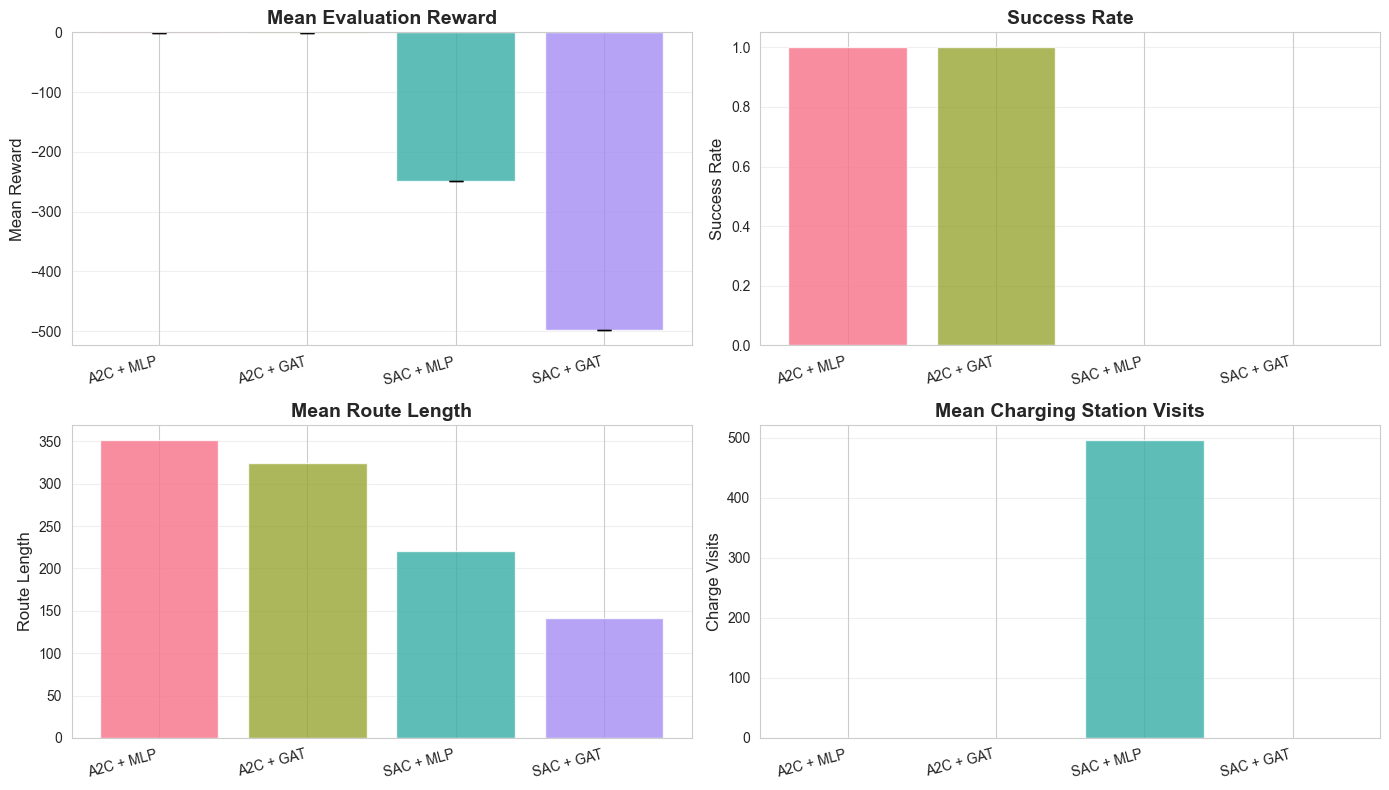

✓ Performance comparison plotted


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Bar plot: Mean Reward
ax = axes[0, 0]
names = list(performance_summary.keys())
mean_rewards = [performance_summary[n]['Mean Reward'] for n in names]
std_rewards = [performance_summary[n]['Std Reward'] for n in names]
colors = sns.color_palette("husl", len(names))

bars = ax.bar(range(len(names)), mean_rewards, yerr=std_rewards, 
               capsize=5, color=colors, alpha=0.8)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Mean Reward', fontsize=12)
ax.set_title('Mean Evaluation Reward', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Bar plot: Success Rate
ax = axes[0, 1]
success_rates = [performance_summary[n]['Success Rate'] for n in names]
bars = ax.bar(range(len(names)), success_rates, color=colors, alpha=0.8)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Success Rate', fontsize=12)
ax.set_title('Success Rate', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.05])
ax.grid(True, axis='y', alpha=0.3)

# Bar plot: Route Length
ax = axes[1, 0]
route_lengths = [performance_summary[n]['Mean Route Length'] for n in names]
bars = ax.bar(range(len(names)), route_lengths, color=colors, alpha=0.8)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Route Length', fontsize=12)
ax.set_title('Mean Route Length', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Bar plot: Charge Visits
ax = axes[1, 1]
charge_visits = [performance_summary[n]['Mean Charge Visits'] for n in names]
bars = ax.bar(range(len(names)), charge_visits, color=colors, alpha=0.8)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Charge Visits', fontsize=12)
ax.set_title('Mean Charging Station Visits', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/ablation/performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Performance comparison plotted")

## 6. Conclusions

Based on the ablation study, we can draw the following conclusions:

### Algorithm Comparison (A2C vs SAC)
- **A2C**: On-policy algorithm, simpler, faster training per episode
- **SAC**: Off-policy algorithm, better sample efficiency, automatic entropy tuning

### Encoder Comparison (MLP vs GAT)
- **MLP**: Simpler baseline, faster computation, treats nodes independently
- **GAT**: Graph-aware, captures spatial relationships, potentially better for routing

### Key Findings:
1. Check which combination achieved the best reward
2. Observe if GAT encoders show better spatial understanding
3. Compare sample efficiency between A2C and SAC
4. Analyze charge visit patterns and route optimization

### Next Steps:
- Increase training epochs for more definitive results
- Test on larger problem instances
- Try different hyperparameter configurations
- Implement additional metrics (e.g., optimality gap if optimal solutions available)

## 7. Save Results

Let's save the comparison data for future reference.

In [7]:
# Save performance summary
import json
from pathlib import Path

results_dir = Path('results/ablation')
results_dir.mkdir(parents=True, exist_ok=True)

# Convert numpy types to Python types for JSON serialization
summary_serializable = {}
for name, metrics in performance_summary.items():
    summary_serializable[name] = {
        k: float(v) if isinstance(v, (np.floating, np.integer)) else v
        for k, v in metrics.items()
    }

with open(results_dir / 'ablation_summary.json', 'w') as f:
    json.dump(summary_serializable, f, indent=2)

# Save dataframe
df.to_csv(results_dir / 'ablation_summary.csv')

print("✓ Results saved to:")
print(f"  - {results_dir / 'ablation_summary.json'}")
print(f"  - {results_dir / 'ablation_summary.csv'}")
print(f"  - {results_dir / 'training_comparison.png'}")
print(f"  - {results_dir / 'performance_comparison.png'}")

✓ Results saved to:
  - results/ablation/ablation_summary.json
  - results/ablation/ablation_summary.csv
  - results/ablation/training_comparison.png
  - results/ablation/performance_comparison.png


---

## Summary

This notebook demonstrated the **Modular RL Framework** for EVRP:

✅ **Config-driven experiments**: Easy to define and modify configurations  
✅ **Multiple algorithms**: A2C and SAC agents  
✅ **Multiple encoders**: MLP and GAT graph encoders  
✅ **Automated training**: ExperimentRunner handles training loops, evaluation, and checkpointing  
✅ **Comprehensive metrics**: Rewards, losses, success rates, route lengths, charge visits  
✅ **Visualization**: Training curves and performance comparisons  

The framework is fully modular and extensible:
- Add new algorithms by implementing `BaseAgent`
- Add new encoders by implementing `Encoder`
- Customize rewards with `RewardModule`
- Control action masking with `MaskModule`

**Next steps**: Use the framework to run larger-scale experiments, tune hyperparameters, and deploy trained agents!